Warning for 2026-08-10: 107 files, 121 sweep values. Using first 107.
Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySWAP1D_len_loop_20260810_1634_to_20260810_1702_MAG.npz


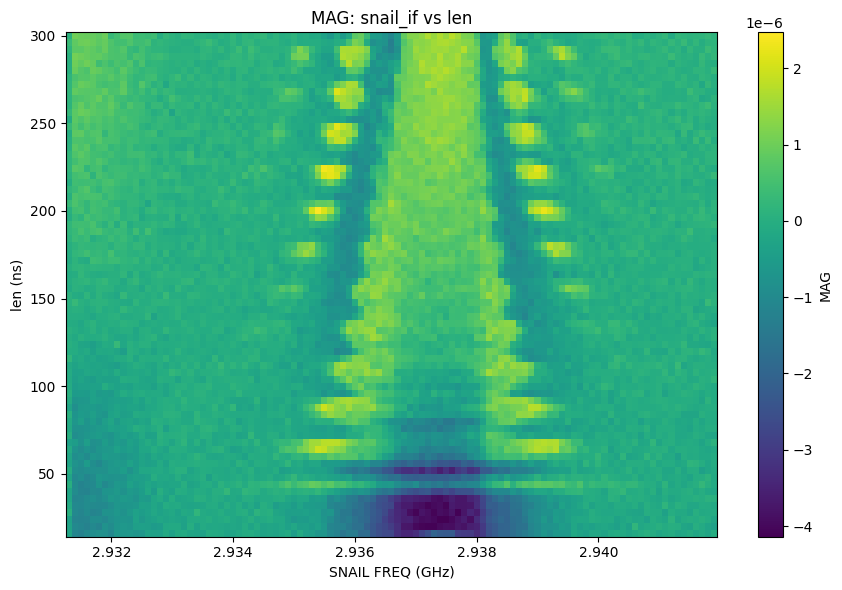

In [16]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True

# ----------------------------------------------------------
# Outer sweep
# Can be ANY sweep: current, IF, pulse length, amplitude, etc.
# ----------------------------------------------------------

IF_sweep = np.linspace(start=11.3e6-6e6, stop=11.3e6+6e6, num=121)

lo = 3.676e9 + 50e6 - 800e6  # Hz

batches = [
    # {
    #     "date": "2026-08-08",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
    #     "time": ((11, 58), (12, 1)),
    #     "sweep": current_A_print,
    #     "lo": lo,
    # },
    {
        "date": "2026-08-10",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
        "time": ((16, 34), (17, 2)),
        "sweep": IF_sweep,
        "lo": lo,
    },
]

file_key = "CavitySWAP1D_len_loop"

plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None               # None -> auto-choose inner sweep axis
subtract_mean = True

# Axis labels
x_label = "snail_if"
y_label = "len"

# Optional scaling for plotting only
# Examples:
#   current A -> mA: x_scale = 1e3
#   Hz -> MHz:       x_scale = 1e-6
#   seconds -> us:   x_scale = 1e6
x_scale = 1e-9
y_scale = 1#1e-9

x_plot_label = "SNAIL FREQ (GHz)"
y_plot_label = "len (ns)"

show_individual_plots = False

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
)
os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# Generate output filename
# ==========================================================

st_d = batches[0]["date"].replace("-", "")
end_d = batches[-1]["date"].replace("-", "")

st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]

save_npz_name = (
    f"{file_key}_"
    f"{st_d}_{st_h:02d}{st_m:02d}_"
    f"to_"
    f"{end_d}_{end_h:02d}{end_m:02d}_"
    f"{plot_data}.npz"
)

npz_path = os.path.join(output_folder, save_npz_name)

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================


def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return int(parts[0]), int(parts[1])
    except Exception:
        return -1, -1


def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".hdf5") and file_key in f
    ]

    return sorted(
        f
        for f in files
        if start_time <= extract_time(f) <= end_time
    )


def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(
            k for k in f.keys()
            if k not in {"I", "Q", "Magnitude"}
        )

        y_vals = np.array(f[key][()])

        I_val = (
            np.mean(f["I"][()], axis=0)
            if f["I"].ndim > 1
            else np.array(f["I"][()])
        )

        Q_val = (
            np.mean(f["Q"][()], axis=0)
            if f["Q"].ndim > 1
            else np.array(f["Q"][()])
        )

        mag_val = (
            np.mean(f["Magnitude"][()], axis=0)
            if "Magnitude" in f.keys()
            else np.sqrt(I_val**2 + Q_val**2)
        )

        if subtract_mean:
            I_val = I_val - np.mean(I_val)
            Q_val = Q_val - np.mean(Q_val)
            mag_val = mag_val - np.mean(mag_val)

    return key, y_vals, I_val, Q_val, mag_val


def base_mesh_plot(x, y, z, title_suffix=""):
    """Generic 2D mesh plot."""

    plt.figure(figsize=(9, 6))

    x_plot = np.asarray(x) * x_scale
    y_plot = np.asarray(y) * y_scale

    plt.pcolormesh(
        x_plot,
        y_plot,
        z.T,
        shading="auto",
        cmap="viridis",
    )

    plt.xlabel(x_plot_label)
    plt.ylabel(y_plot_label)

    title = f"{plot_data}: {x_label} vs {y_label}"
    if title_suffix:
        title += f" {title_suffix}"

    plt.title(title)
    plt.colorbar(label=plot_data)
    plt.tight_layout()


# ==========================================================
# PROCESS HDF5 -> NPZ
# ==========================================================

if build_npz_from_hdf5:

    grouped_files = []
    x_values = []
    file_dates = []
    file_times = []

    for b in batches:

        files = get_filtered_files(
            b["folder"],
            b["time"][0],
            b["time"][1],
            file_key,
        )

        n = min(len(files), len(b["sweep"]))

        if len(files) != len(b["sweep"]):
            print(
                f'Warning for {b["date"]}: '
                f'{len(files)} files, '
                f'{len(b["sweep"])} sweep values. '
                f'Using first {n}.'
            )

        grouped_files.extend(files[:n])
        x_values.extend(b["sweep"][:n])

        file_dates.extend(
            [b["date"]] * n
        )

        file_times.extend(
            [extract_time(f) for f in files[:n]]
        )

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    x_values = np.asarray(x_values)

    I_2d = []
    Q_2d = []
    MAG_2d = []
    sweep_axis = []

    for fname in grouped_files:

        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(
            fname,
            y_key,
            subtract_mean,
        )

        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    sweep_axis = np.asarray(sweep_axis)
    y_values = sweep_axis[0]

    I_2d = np.asarray(I_2d)
    Q_2d = np.asarray(Q_2d)
    MAG_2d = np.asarray(MAG_2d)

    np.savez_compressed(
        npz_path,

        # Generic axes
        x_values=x_values,
        y_values=y_values,
        sweep_axis=sweep_axis,

        # Data
        I=I_2d,
        Q=Q_2d,
        MAG=MAG_2d,

        # Axis information
        x_label=x_label,
        y_label=y_label,
        y_key=key,
        x_scale=x_scale,
        y_scale=y_scale,
        x_plot_label=x_plot_label,
        y_plot_label=y_plot_label,

        # File information
        filenames=grouped_files,
        file_dates=file_dates,
        file_times=file_times,

        # Batch information
        batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches],
        batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches],

        # Other settings
        file_key=file_key,
        subtract_mean=subtract_mean,
        plot_data_saved=plot_data,
    )

    print(f"Saved main NPZ to: {npz_path}")


# ==========================================================
# ANALYSIS
# ==========================================================

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["x_values"]#+ lo
    y_values = data["y_values"] 
    data_2d = data[plot_data]

    # Raw 2D mesh plot
    base_mesh_plot(
        x_values+lo,
        y_values,
        data_2d,
    )

    plt.show()